# $(SASA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1801,6,71,"(0.101516037315209, 0.2595372644863228)","(-0.062, -0.008, 0.136, 0.246)",1,1.0,"(-0.062, 0.196, 0.141, -0.23)",1.0,1.0,"(-0.058, 0.399, 0.137, -0.703)"
523,75,19,"(0.0642916329828742, 1.239005358213764)","(0.232, 0.948, 0.125, 0.027)",1,1.0,"(0.251, 1.135, 0.126, -0.071)",0.0,1.0,"(0.273, 0.947, 0.124, 0.058)"
1741,15,69,"(0.1433033517266329, 1.8075969481187537)","(-0.047, -0.186, 0.077, 0.177)",1,1.0,"(-0.051, -0.001, 0.081, 0.101)",0.0,1.0,"(-0.051, -0.187, 0.083, 0.191)"
238,3,8,"(0.1426982404803344, 0.3806655964596813)","(-0.01, 0.25, -0.025, -0.394)",0,1.0,"(-0.005, 0.05, -0.033, -0.008)",1.0,1.0,"(-0.004, 0.251, -0.033, -0.418)"
2093,50,81,"(0.1825292152212203, 0.91730535067745)","(0.214, 0.325, 0.084, 0.219)",0,1.0,"(0.221, 0.135, 0.089, 0.404)",0.0,1.0,"(0.223, -0.055, 0.097, 0.589)"
...,...,...,...,...,...,...,...,...,...,...
416,12,15,"(0.4832980502500528, 0.5461494126807303)","(0.011, 0.033, -0.004, -0.083)",1,1.0,"(0.012, 0.232, -0.005, -0.457)",1.0,1.0,"(0.017, 0.431, -0.014, -0.832)"
242,7,8,"(0.1426982404803344, 0.3806655964596813)","(0.002, 0.252, -0.042, -0.45)",1,1.0,"(0.007, 0.453, -0.051, -0.864)",1.0,1.0,"(0.016, 0.654, -0.068, -1.282)"
2240,5,88,"(0.4162542062822604, 0.4644156025476709)","(-0.035, -0.182, 0.039, 0.466)",1,1.0,"(-0.039, 0.018, 0.048, 0.073)",1.0,1.0,"(-0.039, 0.217, 0.049, -0.315)"
885,9,36,"(0.0299166252862626, 0.5232478091465481)","(0.051, 0.184, -0.075, -0.279)",0,1.0,"(0.055, -0.009, -0.08, -0.035)",0.0,1.0,"(0.055, -0.202, -0.081, 0.207)"


In [3]:
model = Base_Line_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.2177438884973526, 0.6936059594154358, 0.086...",1.943224,1.054707
1,1,"[0.2139989137649536, 0.686985433101654, 0.0845...",1.921525,1.051102
2,2,"[0.21029701828956604, 0.6803996562957764, 0.08...",1.900002,1.047548
3,3,"[0.2066257894039154, 0.6738412976264954, 0.080...",1.878653,1.044044
4,4,"[0.20298179984092712, 0.6673067212104797, 0.07...",1.857478,1.040588


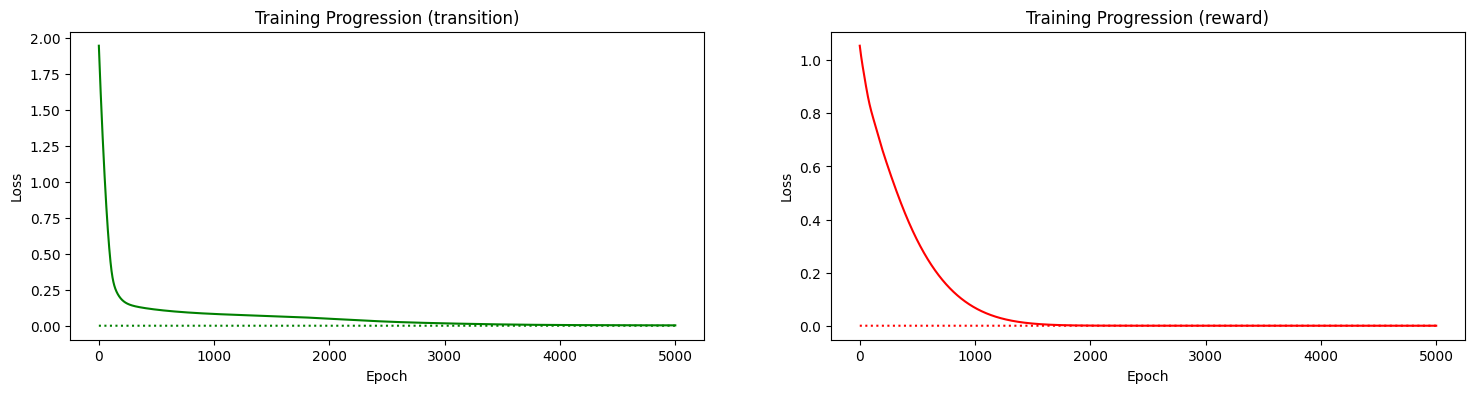

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

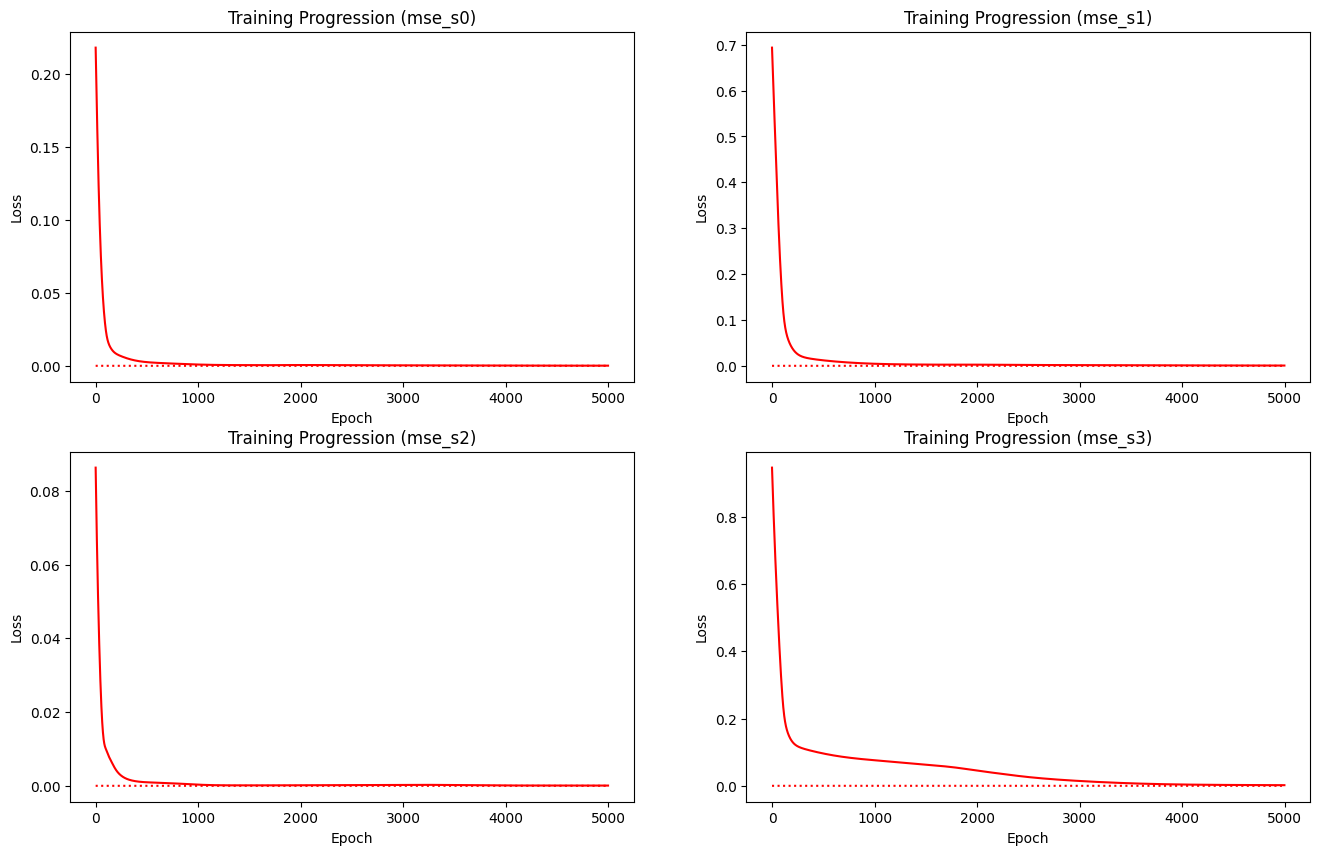

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

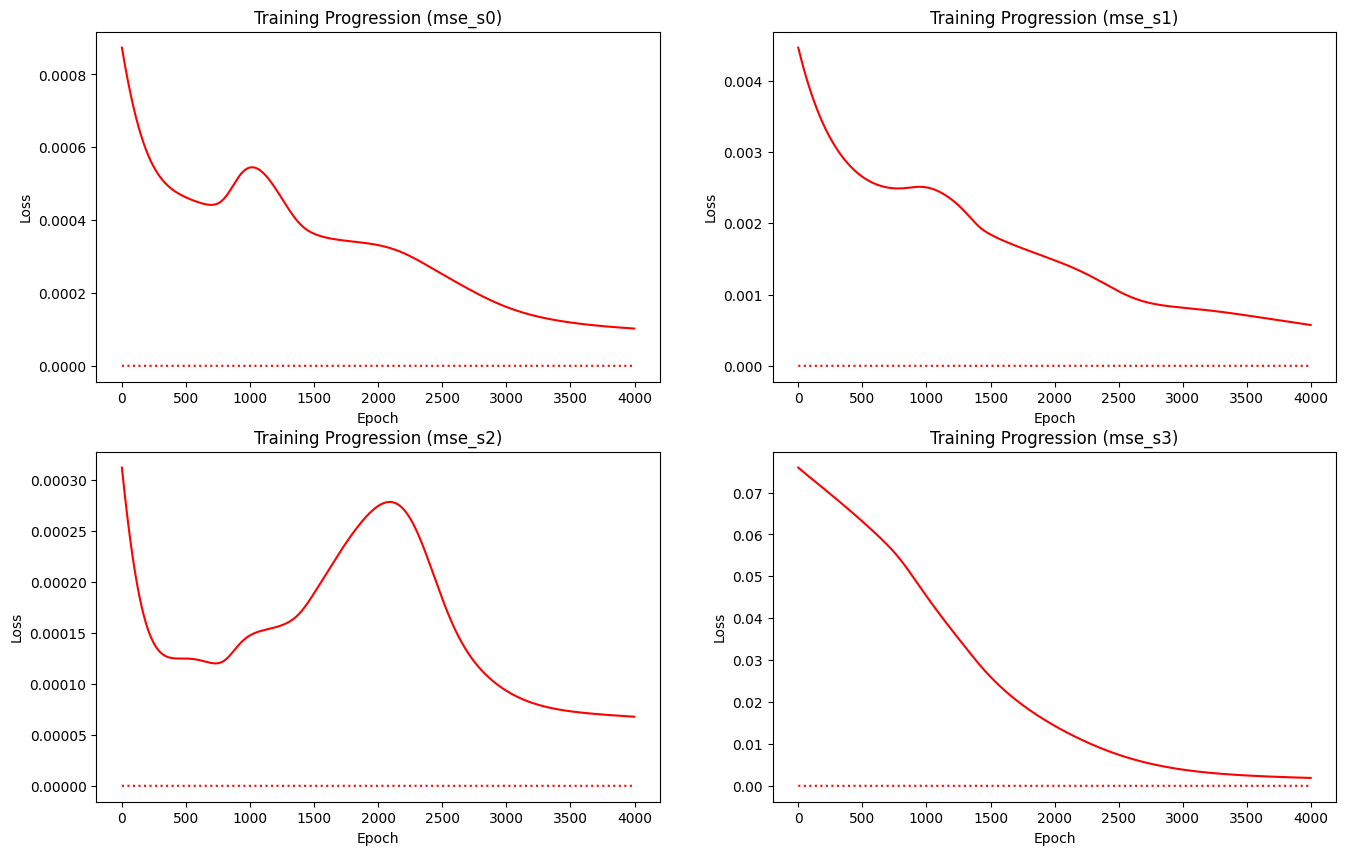

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

# df = get_data_expanded(train_data[train_data.epoch>3000].reset_index(drop=True), expansions)
df = get_data_expanded(train_data[train_data.epoch>1000].reset_index(drop=True), expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [7]:
data.evaluate_model(model, path='../testing_data.csv')
results = data.get_evaluation_metrics(p=False)
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.002,0.009,0.232,0.0,0.546990,0.526549,0.522782,0.454522,0.244,0.512711
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.015,0.023,0.022,0.0,0.552270,0.529744,0.556355,0.436553,0.066,0.518731
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.056,0.024,0.078,0.0,0.553326,0.539823,0.558753,0.441345,0.165,0.523312
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.006,0.030,0.111,0.0,0.549102,0.527532,0.573141,0.444169,0.150,0.523486
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.071,0.040,0.232,0.0,0.558606,0.543510,0.597122,0.454522,0.355,0.538440


In [8]:
results[['rse', 'rse_normalized', 
         'rse_s0', 'rse_s0_normalized',
         'rse_s1', 'rse_s1_normalized', 
         'rse_s2', 'rse_s2_normalized',
         'rse_s3', 'rse_s3_normalized']].describe()

,rse,rse_normalized,rse_s0,rse_s0_normalized,rse_s1,rse_s1_normalized,rse_s2,rse_s2_normalized,rse_s3,rse_s3_normalized
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.049454,0.508246,0.005170,0.551394,0.013983,0.529494,0.005895,0.515335,0.024406,0.436759
std,0.053627,0.005338,0.006905,0.007292,0.017871,0.004393,0.005478,0.013136,0.038898,0.003328
min,0.001000,0.502027,0.000000,0.545935,0.000000,0.526057,0.000000,0.501199,0.000000,0.434671
25%,0.022000,0.505008,0.001000,0.546990,0.005000,0.527286,0.002000,0.505995,0.006000,0.435184
50%,0.035000,0.506888,0.003000,0.549102,0.010000,0.528515,0.005000,0.513189,0.013000,0.435783
75%,0.054000,0.509419,0.006000,0.552270,0.017000,0.530236,0.008000,0.520384,0.027000,0.436981
max,0.666000,0.556865,0.087000,0.637804,0.307000,0.601524,0.044000,0.606715,0.416000,0.470266


In [9]:
import numpy as np 
n = 10

worst = results.loc[results.rank(ascending=False)['rse']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/pyt

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

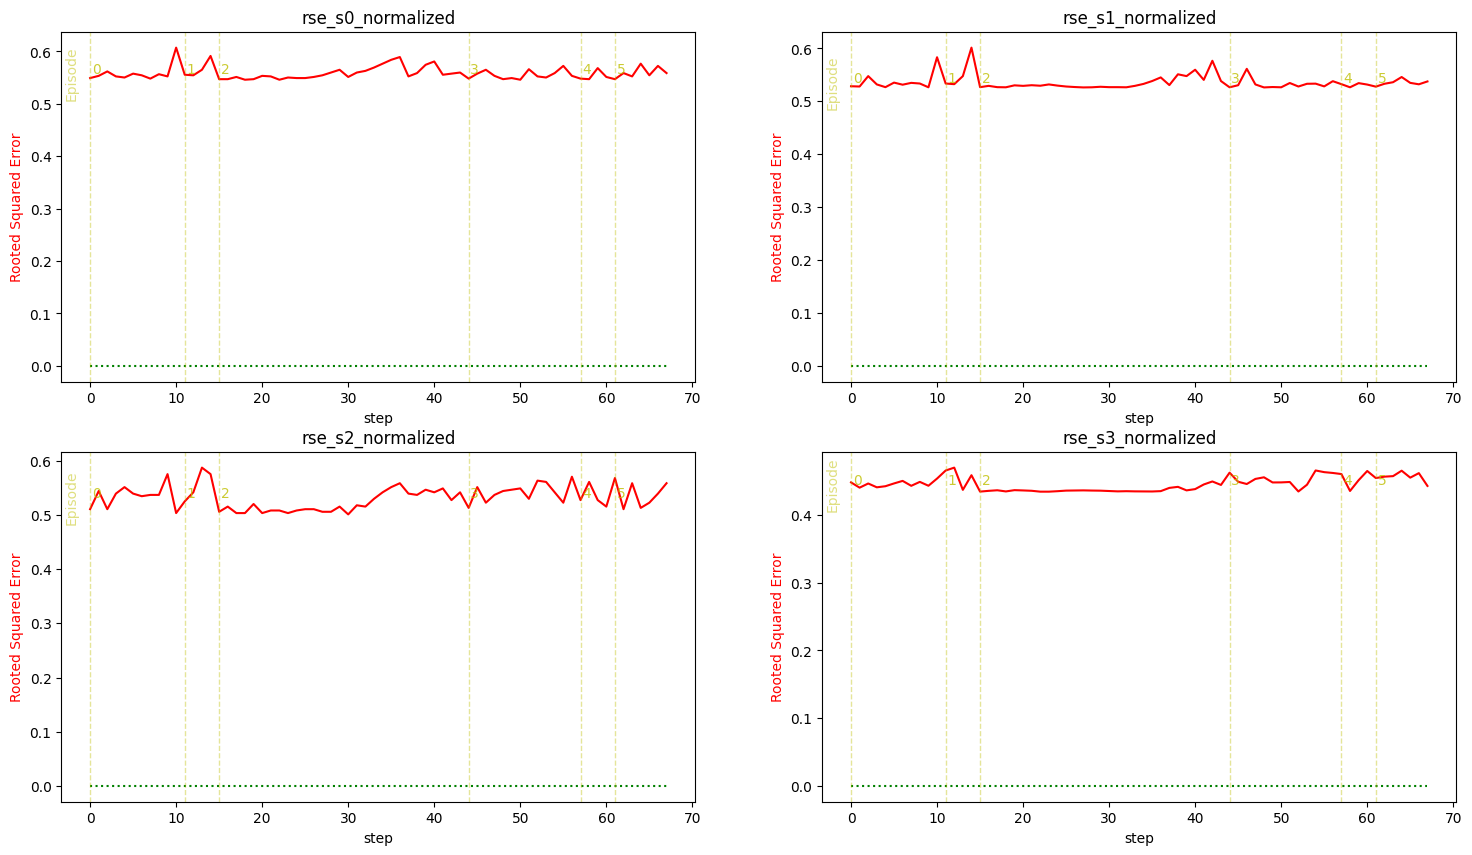

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], df, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], df, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], df, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], df, 'rse_s3_normalized')

plt.show()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


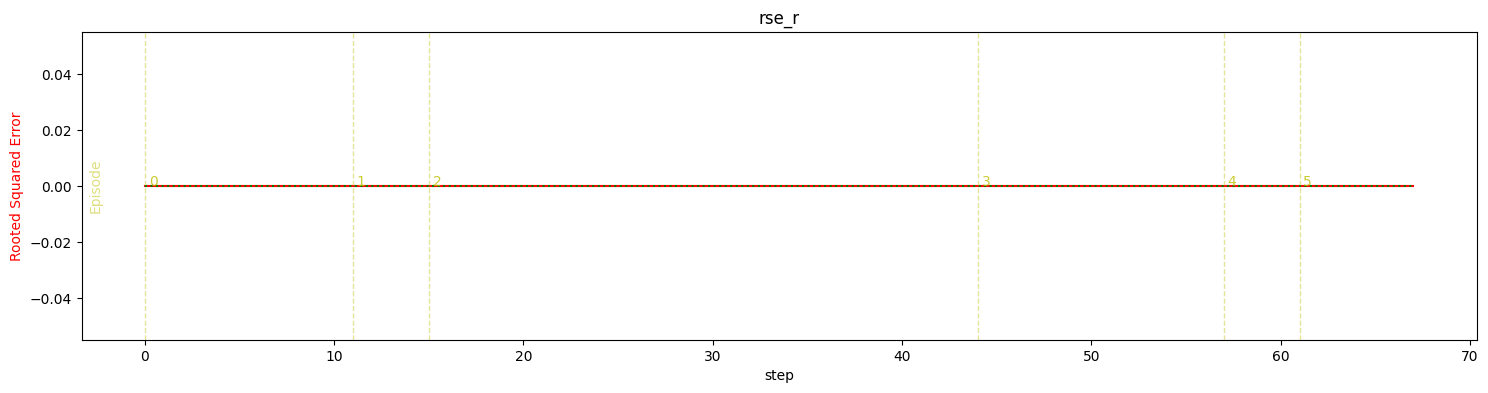

In [11]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, df, 'rse_r')
plt.show()

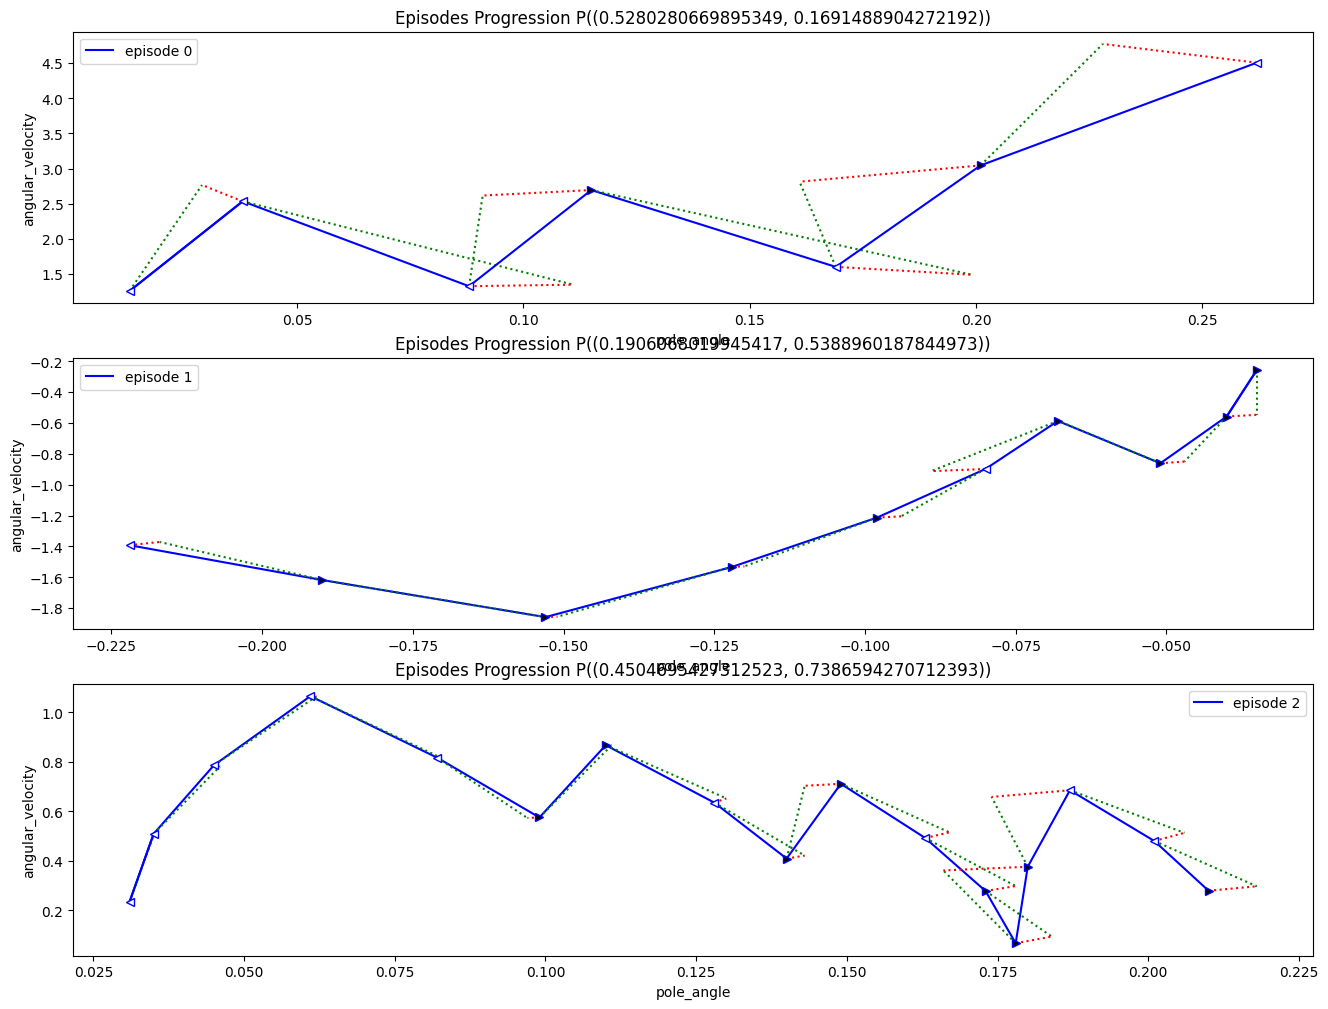

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()